PREDICTIVE MODELING WITH ML

TASK 0-IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

TASK 1-LOAD THE DATASET

In [2]:
data = pd.read_csv("student_performance_linear_regression_500.csv")

TASK 2-VIEW FIRST 5 ROWS

In [3]:
data.head()

,Hours_Studied,Attendance_Percentage,Previous_Exam_Score,Final_Exam_Score
0,7.85,86.84,34.34,81.69
1,4.67,94.32,62.08,60.96
2,8.66,96.05,39.03,80.28
3,7.12,75.18,40.66,73.95
4,1.39,76.01,74.26,48.61


TASK 3-CHECK DATASET INFORMATION

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hours_Studied          500 non-null    float64
 1   Attendance_Percentage  500 non-null    float64
 2   Previous_Exam_Score    500 non-null    float64
 3   Final_Exam_Score       500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


TASK 4-CHECK FOR MISSING VALUES

In [5]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance_Percentage,0
Previous_Exam_Score,0
Final_Exam_Score,0


TASK 5-DISPLAY STATISTICAL SUMMARY

In [6]:
data.describe()

,Hours_Studied,Attendance_Percentage,Previous_Exam_Score,Final_Exam_Score
count,500.000000,500.000000,500.000000,500.000000
mean,5.209120,74.933820,65.320340,64.248500
std,2.724287,14.830178,20.406533,17.903347
min,0.550000,50.060000,30.040000,18.500000
25%,2.742500,62.165000,47.225000,49.755000
50%,5.260000,74.685000,64.475000,64.015000
75%,7.595000,88.172500,83.132500,78.832500
max,9.990000,99.940000,99.960000,100.000000


TASK 6-DEFINE FEATURES(X) AND (Y)

In [7]:
X = data[['Hours_Studied',
          'Attendance_Percentage',
          'Previous_Exam_Score']]

y = data['Final_Exam_Score']

TASK 7-SPLIT INTO TRAINING AND TESTING DATA

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

TASK 8-CREATE THE LINEAR REGRESSION MODEL

In [9]:
model = LinearRegression()

TASK 9-TRAIN THE MODEL

In [10]:
model.fit(X_train, y_train)

LinearRegression()

TASK 10-PREDICT THE TEST DATA

In [11]:
y_pred = model.predict(X_test)

TASK 11-COMPARE ACTUAL AND PREDICTED VALUES

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
361,46.98,43.400407
73,52.99,58.782429
374,57.36,54.477307
155,70.13,66.582053
104,75.67,80.223326
394,46.44,44.353678
377,64.49,64.872921
124,40.88,42.200093
68,18.50,29.091190
450,39.40,43.203566


TASK 12-CALCULATE MEAN ABSOLUTE ERROR(MAE)

In [13]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.000275918006193


TASK 13-CALCULATE MEAN SQUARED ERROR (MSE)

In [14]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 25.30885412907256


TASK 14-CALCULATE ROOT MEAN SQUARED ERROR(RMSE)

In [15]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5.030790606760786


TASK 15-CALCULATE R² SCORE

In [16]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9343532650434451


TASK 16-PRINT MODEL COEFFICIENT

In [17]:
print("Intercept:", model.intercept_)

print("Coefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept: 3.163426014062459
Coefficients:
Hours_Studied : 6.06848079399239
Attendance_Percentage : 0.2095402636414223
Previous_Exam_Score : 0.21548460443415296


TASK 17-VISUALIZE ACTUAL AND PREDICTED VALUES

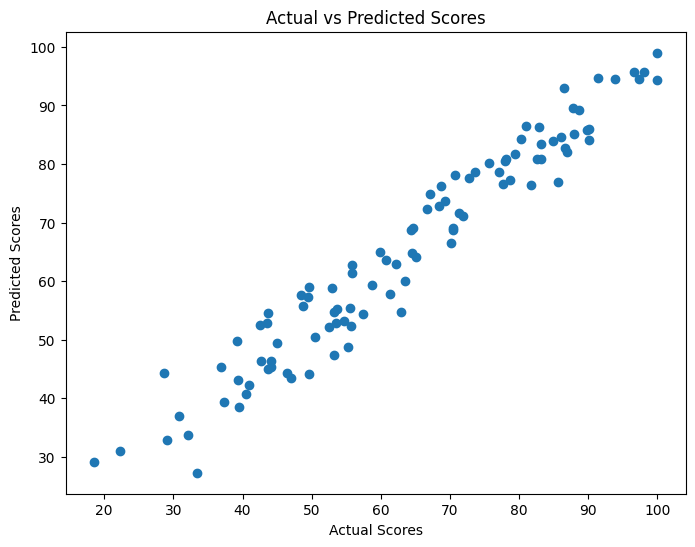

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Scores")

plt.show()

TASK 18-PREDICT FOR A NEW STUDENT

In [19]:
new_student = [[8, 90, 75]]

prediction = model.predict(new_student)

print("Predicted Final Score:", prediction[0])

Predicted Final Score: 86.73124142629106


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


TASK 19-SAVE THE TRAINED MODEL

In [20]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [21]:
loaded_model = joblib.load("linear_regression_model.pkl")